# Tutorial 1: Matched Filtering

We will compute the matched filter signal-to-noise ratio (SNR) for a representative signal in noisy data using two methods:
- Direct dot product in time domain
- Fast Fourier Transform (FFT) based matched filtering in frequency domain.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [1]:
# !pip install numpy matplotlib time scipy

In [2]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

import matplotlib.pyplot as plt
import time

from scipy.linalg import circulant
from scipy.fft import fft, ifft

In [3]:
def sine_gaussian(t, A, f0, t0, Q, phi0=0):
    tau = Q / (np.sqrt(2) * np.pi * f0)  # approximate envelope timescale
    return A * np.exp(-((t - t0)**2) / (2 * tau**2)) * np.sin(2*np.pi*f0*(t-t0) + phi0)

In [4]:
# Generate sine-Gaussian template and data (fs=1024 Hz, duration=2 s)
fs = 1024
duration = 1
N = int(fs * duration)
t = np.arange(N) / fs

# Sine-Gaussian parameters
f0 = 100.0   # Hz
Q = 6.0
t0 = duration / 2.0 # centered in the middle of the time series)
A = 3
h = sine_gaussian(t, A, f0, t0, Q, phi0=0)

# Simulated white Gaussian noise and data x = h + noise
sigma_noise = 1.0
noise = np.random.normal(0, sigma_noise, size=N)
x = h + noise


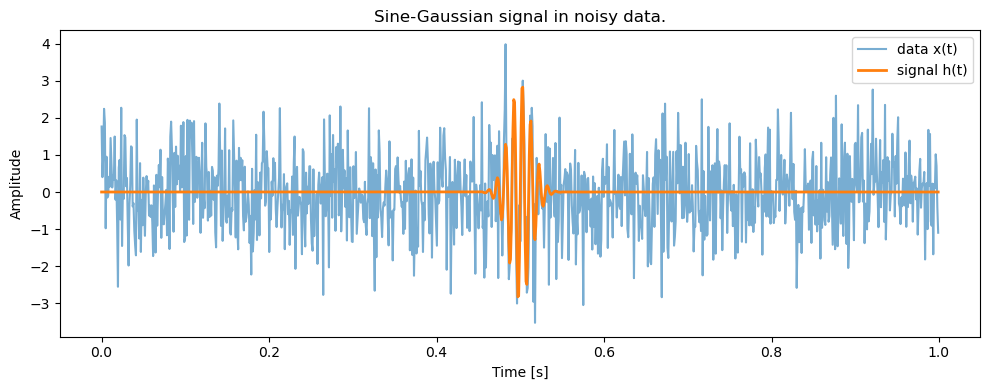

In [5]:
plt.figure(figsize=(10,4))
plt.plot(t, x, label='data x(t)', alpha=0.6)
plt.plot(t, h, label='signal h(t)', linewidth=2)
# plt.xlim(t0-0.4, t0+0.4)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Sine-Gaussian signal in noisy data.')
plt.legend()
plt.tight_layout()


In [6]:
C = sigma_noise**2 * np.eye(N)  # We have white Gaussian noise. White --> independent of frequency.

C_inv = np.linalg.inv(C)


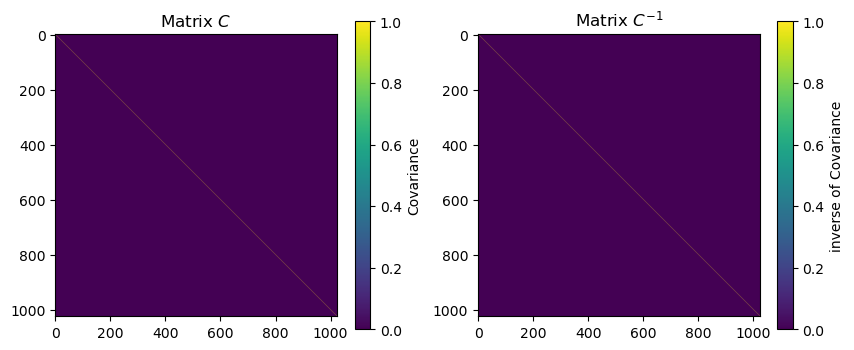

In [7]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax1, ax2 = ax[0], ax[1]

im1 = ax1.imshow(C, cmap='viridis')
fig.colorbar(im1, label='Covariance')
ax1.set_title(r"Matrix $C$")

im2 = ax2.imshow(C_inv, cmap='viridis')
fig.colorbar(im2, label='inverse of Covariance')
ax2.set_title(r"Matrix $C^{-1}$")
plt.show()

The matched-filter output of the data $s(t)$ using a reference signal $h(t)$ (template) at a time lag $\tau$ can be written as,

$$
\rho(\tau) = (s, h_\tau),
$$

where $h_\tau(t)$ is the template shifted by $\tau$.

Computing this directly requires evaluating the overlap for every possible shift of the template:
$$
\bf{\rho}_k
=
\bf{s}_i^T\, \bf{C}_{ij}^{-1}\,\bf{h}_{j,\,k}
$$
where, $\bf{h}_{j,\,k}$ denotes the cyclically time-shifted template (shifted by by $k$ samples).

In [8]:
# Template should be rolled so that we have trigger at the central time (convention).
template = np.roll(h, int(fs * t0))

## Normalize the template
norm_h = np.sqrt(np.dot(template, C_inv @ template))
template /= norm_h

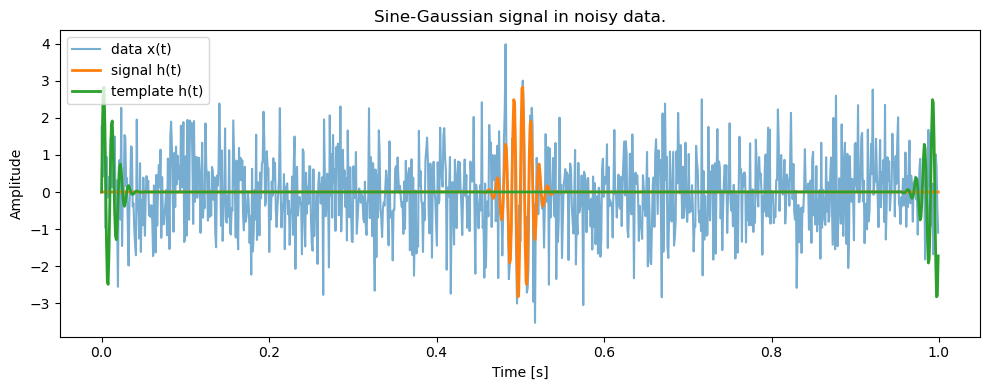

In [9]:
plt.figure(figsize=(10,4))
plt.plot(t, x, label='data x(t)', alpha=0.6)
plt.plot(t, h, label='signal h(t)', linewidth=2)
plt.plot(t, template*norm_h, label='template h(t)', linewidth=2)
# plt.xlim(t0-0.4, t0+0.4)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Sine-Gaussian signal in noisy data.')
plt.legend()
plt.tight_layout()


In [10]:
## matched filter using dot product.
matched_filter_dp1 = []

start = time.perf_counter()
for i in range(N):
    template_rolled = np.roll(template, i)
    matched_filter_dp1.append(np.dot(template_rolled, C_inv @ x))
end = time.perf_counter()

print(f'Time taken = {end - start}')
matched_filter_dp1 = np.array(matched_filter_dp1)

Time taken = 0.2780554089695215


In [11]:
## More efficient way:

start = time.perf_counter()

H = circulant(template).T
matched_filter_dp = H @ (C_inv @ x)

end = time.perf_counter()

print(f'Time taken = {end - start}')

Time taken = 0.0012334450148046017


[]

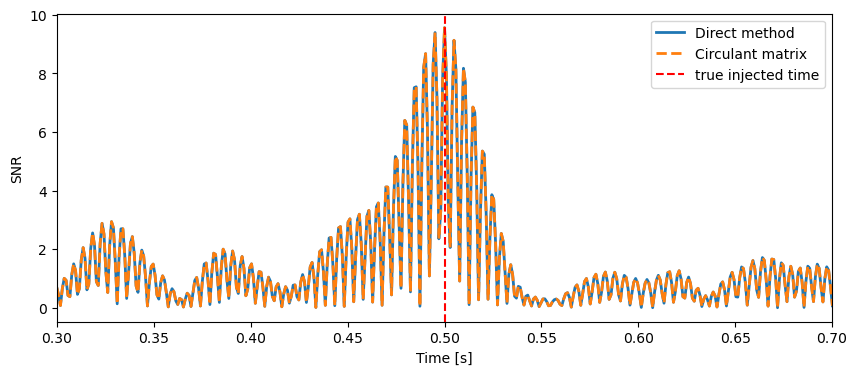

In [12]:
plt.figure(figsize=(10,4))
plt.plot(t, abs(matched_filter_dp1), linewidth=2, label = 'Direct method')
plt.plot(t, abs(matched_filter_dp), linewidth=2, ls = '--', label = 'Circulant matrix')
plt.xlim(t0-0.2, t0+0.2)
plt.axvline(t0,color='red', linestyle='--', label='true injected time')
plt.xlabel('Time [s]')
plt.ylabel('SNR')
plt.legend()
plt.plot()

# Maximize inner-product over unknown phase.

Calculating inner products at circular time-shifts can be used to maximise over time (just by taking the maximum value of snr timeseries). But, the signal has an unkown phase because of which the SNR time series looks wiggly. We need to maximise SNR over the phase as well.

Suppose the signal in the data is

$$
s(t)=A\cos(2\pi f t+\phi_0),
$$

where:

* $A$ is the amplitude,
* $f$ is the frequency,
* $\phi_0$ is an unknown phase.

Now suppose we use only a cosine template: $h_c(t)=\cos(2\pi f t).$

The matched filter computes the inner product: $(s,h_c).$

The signal can be rewritten as,

$$
s(t)
=
A\cos\phi_0\;\cos\omega t -

A\sin\phi_0\;\sin\omega t, \quad \quad \omega = 2 \pi f
$$
It shows that a signal with arbitrary phase is not represented by a single template. Instead, it lives in a two-dimensional space spanned by:

* cosine phase: $h_c(t)=\cos\omega t,$

* sine phase: $h_s(t)=\sin\omega t.$

These are called the **quadrature templates**.

Now, we also compute $(s,h_s)\propto A\sin\phi_0.$

We now have two matched-filter outputs:

$
\rho_c=(s,h_c),
\qquad
\rho_s=(s,h_s).
$

Construct the complex SNR time series,

$$
\rho
= \rho_c + i \rho_s,
$$
The SNR is then given by the magnitude of the complex SNR:
$$
|\rho| = \sqrt{\rho_c^2+\rho_s^2}. 
$$
Substituting the phase dependence,

$$
|\rho|^2
=

A^2\cos^2\phi_0
+
A^2\sin^2\phi_0
=
A^2.
$$

The phase dependence disappears completely. This is called **maximization over phase**.

In [13]:
## Maximize over phase
Q = 6
tau = Q / (np.sqrt(2) * np.pi * f0)
h_cos = np.exp(-((t - t0)**2) / (2 * tau**2)) * np.cos(2 * np.pi * f0 * (t - t0))
h_sin = np.exp(-((t - t0)**2) / (2 * tau**2)) * np.sin(2 * np.pi * f0 * (t - t0))

## Roll the template
h_sin = np.roll(h_sin, int(fs * t0))
h_cos = np.roll(h_cos, int(fs * t0))

h_sin /= np.sqrt(np.sum(h_sin**2))
h_cos /= np.sqrt(np.sum(h_cos**2))

In [14]:
start = time.perf_counter()

H_cos = circulant(h_cos).T
H_sin = circulant(h_sin).T
rho_dp_cos = H_cos @ (C_inv @ x)
rho_dp_sin = H_sin @ (C_inv @ x)

end = time.perf_counter()

complex_rho_dp = rho_dp_cos + 1j * rho_dp_sin
rho_abs_dp = abs(complex_rho_dp)

print(f'Time taken = {end - start}')

Time taken = 0.016032000072300434


[]

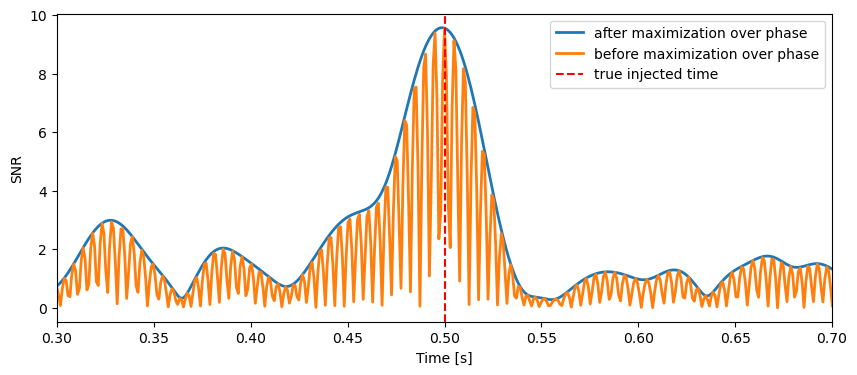

In [15]:
plt.figure(figsize=(10,4))
plt.plot(t, abs(rho_abs_dp), linewidth=2, label = 'after maximization over phase')
plt.plot(t, abs(matched_filter_dp), linewidth=2, label = 'before maximization over phase')
plt.xlim(t0-0.2, t0+0.2)
plt.axvline(t0,color='red', linestyle='--', label='true injected time')
plt.xlabel('Time [s]')
plt.ylabel('SNR')
plt.legend()
plt.plot()


Recall that the matched-filter output at a time lag $\tau$ can be written as

$$
\rho(\tau) = (s, h_\tau),
$$

where $h_\tau(t)$ is the template shifted by $\tau$. If the data contain $N$ samples, then:

1. Computing a single inner product requires $\mathcal{O}(N)$ operations.
2. Evaluating the matched filter for all possible time shifts requires $N$ such inner products.

Therefore, the total computational cost scales as

$$
\mathcal{O}(N^2).
$$

## The Discrete Fourier Transform (DFT)

The Discrete Fourier Transform (DFT) decomposes a discrete time series into its frequency components.

For a sequence $x[n]$ of length $N$, the DFT is defined as

$$
X[k]
=
\sum_{n=0}^{N-1}
x[n]
e^{-2\pi i kn/N}.
$$

The inverse transform reconstructs the original time series:

$$
x[n]
=
\frac{1}{N}
\sum_{k=0}^{N-1}
X[k]
e^{2\pi i kn/N}.
$$

In practice, we use the Fast Fourier Transform (FFT), which computes the DFT in

$$
\mathcal{O}(N\log N)
$$

operations instead of $\mathcal{O}(N^2)$.

In Python, these operations are implemented using

```python
from scipy.fft import fft, ifft
```

where:

- `fft(x)` computes the Fourier transform of a time series,
- `ifft(X)` reconstructs the time series from its Fourier representation.


In [16]:
# FFTs

start = time.perf_counter()

Xf = fft(x)
Hf_cos = fft(h_cos)
Hf_sin = fft(h_sin)

rho_sin = ifft(Xf * np.conj(Hf_cos))
rho_cos = ifft(Xf * np.conj(Hf_sin))

rho_complex = rho_cos + 1j * rho_sin

end = time.perf_counter()

rho_abs = np.abs(rho_complex)
print(f'Time taken = {end - start} s.')

Time taken = 0.0006874140817672014 s.


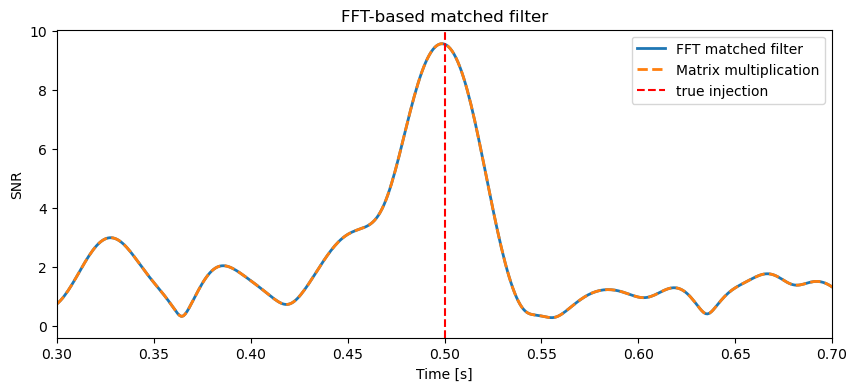

In [17]:
plt.figure(figsize=(10,4))

plt.plot(t, rho_abs, linewidth=2, label='FFT matched filter')
plt.plot(t, rho_abs_dp, label='Matrix multiplication', linewidth=2, ls = '--')

plt.axvline(t0, color='red', linestyle='--', label='true injection')
plt.xlim(t0-0.2, t0+0.2)

plt.xlabel("Time [s]")
plt.ylabel("SNR")
plt.title("FFT-based matched filter")

plt.legend()
plt.show()

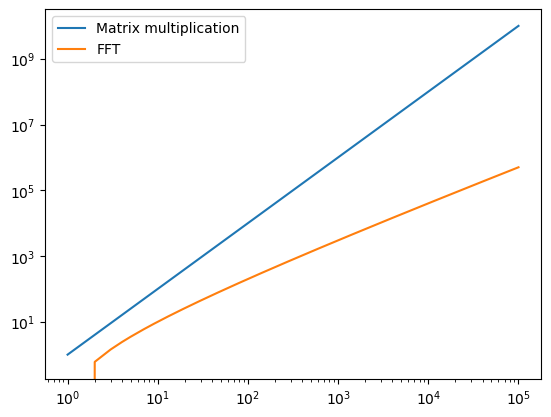

In [18]:
N = int(1e5)
n = np.linspace(1, N, N)

plt.plot(n, n**2, label = 'Matrix multiplication')
plt.plot(n, n*np.log10(n), label = 'FFT')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Problem 1. Comparison of dot product and FFT based approach of matched filtering.
- Repeat above exercise with longer duration of time series data: 4s, 8s, and 16s. 
- Plot the time taken in computation of SNR from each method as a function of total samples in time domain data, N.